In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data =  sns.load_dataset("titanic")

In [6]:
# eda

<Axes: xlabel='sex', ylabel='survived'>

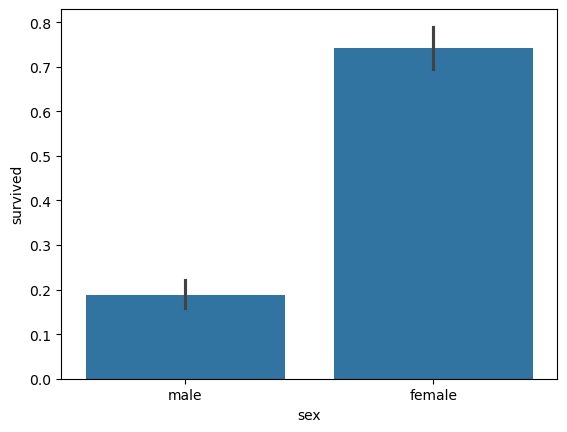

In [7]:
sns.barplot(data=data,x="sex",y="survived")

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


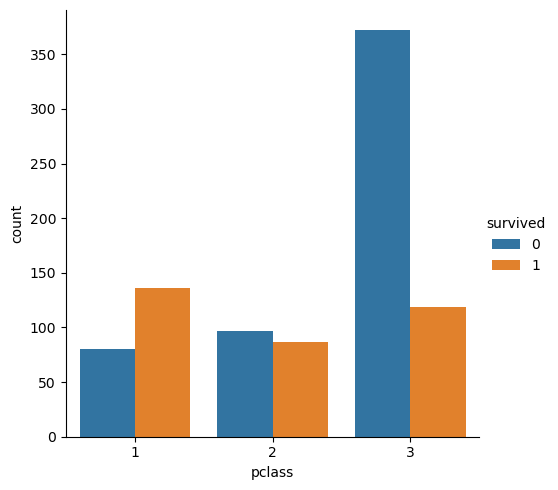

In [9]:
sns.catplot(data=data,x="pclass",hue="survived",kind="count")

<Axes: xlabel='age', ylabel='Count'>

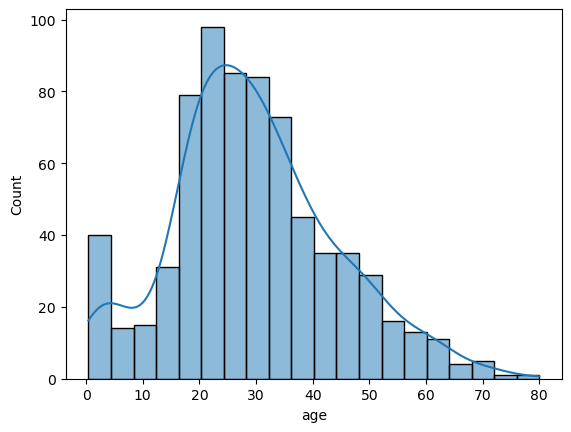

In [10]:
sns.histplot(data=data,x="age",kde=True)

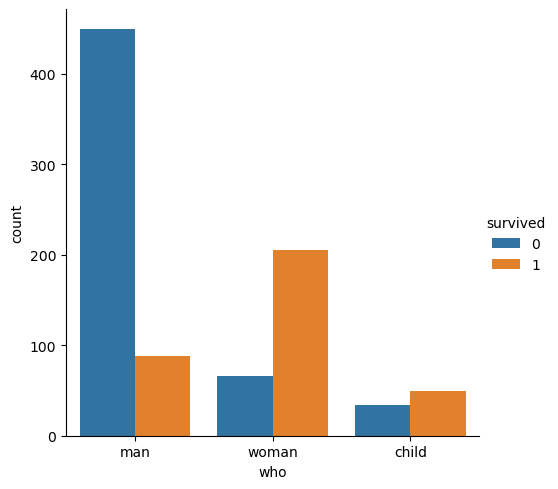

In [11]:
sns.catplot(data=data,x="who",hue="survived", kind="count")

In [12]:
data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [13]:
data = data.drop(["embark_town","deck","alive"],axis=1)

In [14]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,True


In [15]:
data.isna().sum()

survived        0
pclass          0
sex             0
age           177
sibsp           0
parch           0
fare            0
embarked        2
class           0
who             0
adult_male      0
alone           0
dtype: int64

In [16]:
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])

In [17]:
data["embarked"].mode()[0]

'S'

In [18]:
data["age"] = data["age"].fillna(data["age"].median())

In [19]:
data["age"].median()

28.0

In [20]:
data.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alone         0
dtype: int64

In [21]:
data["adult_male"] = data["adult_male"].astype("int")
data["alone"] = data["alone"].astype("int")

In [22]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,1,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,0,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,0,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,0,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,1,1


In [23]:
X = data.drop("survived",axis=1)
y = data["survived"]

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [27]:
categorical_cols = ["sex","class","who","embarked"]

In [28]:
preporcssor = ColumnTransformer(transformers=[
    ("name",OneHotEncoder(drop="first",handle_unknown="ignore"),categorical_cols)
],remainder ="passthrough"
                               )

In [29]:
X_train = preporcssor.fit_transform(X_train)
X_test = preporcssor.transform(X_test)

In [30]:
encoded_cols = preporcssor.get_feature_names_out()

In [31]:
X_train = pd.DataFrame(X_train,columns=encoded_cols)
X_test = pd.DataFrame(X_test,columns=encoded_cols)

In [32]:
X_train

,name__sex_male,name__class_Second,name__class_Third,name__who_man,name__who_woman,name__embarked_Q,name__embarked_S,remainder__pclass,remainder__age,remainder__sibsp,remainder__parch,remainder__fare,remainder__adult_male,remainder__alone
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,28.00,0.0,0.0,30.5000,1.0,1.0
1,1.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,25.00,0.0,0.0,7.0500,1.0,1.0
2,0.0,1.0,0.0,0.0,1.0,0.0,1.0,2.0,24.00,0.0,2.0,14.5000,0.0,0.0
3,1.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,22.00,0.0,0.0,7.5208,1.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.92,1.0,2.0,151.5500,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,0.0,0.0,1.0,0.0,1.0,0.0,1.0,3.0,21.00,0.0,0.0,7.6500,0.0,1.0
664,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,28.00,0.0,0.0,31.0000,1.0,1.0
665,1.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,41.00,2.0,0.0,14.1083,1.0,0.0
666,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,14.00,1.0,2.0,120.0000,0.0,0.0


In [33]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 5.7 MB/s  0:00:00


In [34]:
from sklearn.metrics import classification_report,confusion_matrix

In [35]:
import lightgbm as lgb

In [36]:
clf = lgb.LGBMClassifier(verbosity=-1)
clf.fit(X_train,y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [37]:
y_pred =clf.predict(X_test)

In [38]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       134
           1       0.75      0.78      0.76        89

    accuracy                           0.81       223
   macro avg       0.80      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223

[[111  23]
 [ 20  69]]


In [44]:
from sklearn.model_selection import RandomizedSearchCV

In [45]:
# hyperparameter tuning

In [46]:
lgb_model = lgb.LGBMClassifier(verbosity=-1)

In [47]:
param = {
    "n_estimators" : [100,300,500,],
    "max_depth": [3,5,7,-1],
    "learning_rate" :[0.01,0.05,0.1,0.3],
    "num_leaves" : [15,31,63,127],
    "min_chield_samples" :[10,20,30],
    "supsample" : [0.6,0.8,1],
    "colsample_bytree" : [0.6,0.8,1]
}

In [48]:
rsv = RandomizedSearchCV(estimator=lgb_model,param_distributions=param,cv=5,scoring="accuracy",verbose=1,n_jobs=-1)

In [49]:
rsv.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,LGBMClassifier(verbosity=-1)
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_chield_samples': [10, 20, ...], ...}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [50]:
rsv.best_params_

{'supsample': 0.6,
 'num_leaves': 15,
 'n_estimators': 300,
 'min_chield_samples': 20,
 'max_depth': 3,
 'learning_rate': 0.05,
 'colsample_bytree': 1}

In [51]:
y_pred = rsv.predict(X_test)

In [52]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred));

              precision    recall  f1-score   support

           0       0.85      0.86      0.85       134
           1       0.78      0.76      0.77        89

    accuracy                           0.82       223
   macro avg       0.81      0.81      0.81       223
weighted avg       0.82      0.82      0.82       223

[[115  19]
 [ 21  68]]
